# Milestone 3: Universal Code-Mixed Summarization with Llama 3.1-8B

## Novel Contribution: Zero-Shot Transfer to Unseen Languages

**Research Question:** Can a model trained on Chinese/Tamil/Malay-English generalize to completely unseen language pairs like Japanese-English, Korean-English, and Hindi-English?

### Why Llama 3.1-8B is the Best Choice:
| Feature | Benefit |
|---------|--------|
| 100+ languages in pretraining | Handles Japanese, Korean, Hindi naturally |
| 8B parameters | Strong reasoning and generation |
| Instruction-tuned | Follows summarization instructions well |
| LoRA compatible | Efficient fine-tuning on limited VRAM |

### Experiment Design:
```
Training:    Chinese-En + Tamil-En + Malay-En (ALL ~2,166 examples)
                              ↓
In-Domain:   Test on Chinese-En, Tamil-En, Malay-En
                              ↓  
Zero-Shot:   Test on Japanese-En, Korean-En, Hindi-En (NEVER SEEN!)
```

### Requirements:
- **GPU**: A100 (40GB) recommended, or L4/A10 with aggressive quantization
- **Runtime**: ~4-6 hours for training

---
## Part 0: Setup & Installation

In [ ]:
# Install dependencies
!pip install -q transformers>=4.40.0 datasets accelerate>=0.26.0
!pip install -q peft>=0.10.0 bitsandbytes>=0.43.0 trl>=0.8.0
!pip install -q sentencepiece protobuf
!pip install -q evaluate rouge-score bert-score
!pip install -q pandas numpy matplotlib seaborn tqdm

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 5.8 MB/s eta 0:00:00


In [ ]:
import os
import json
import random
import numpy as np
import pandas as pd
import torch
import gc
from typing import List, Dict, Tuple
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

# Set seeds
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# Check GPU
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU: {gpu_name}")
    print(f"VRAM: {vram:.1f} GB")

    if vram < 20:
        print(f"\n  WARNING: {vram:.1f}GB may be tight for Llama 8B.")
        print("   Using aggressive 4-bit quantization. Consider Colab Pro+ with A100.")
    else:
        print(f"\n✓ Sufficient VRAM for Llama 3.1-8B")

PyTorch: 2.9.0+cu126
CUDA available: True
GPU: NVIDIA A100-SXM4-80GB
VRAM: 85.2 GB

✓ Sufficient VRAM for Llama 3.1-8B


In [ ]:
os.environ['HF_TOKEN']='add your token'

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# ========================================
# UPDATE THESE PATHS!
# ========================================
DATA_DIR = '/content/drive/MyDrive/cs_sum_data/'  # Your CS-SUM data
OUTPUT_DIR = '/content/drive/MyDrive/milestone3_llama8b/'

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"\nData: {DATA_DIR}")
print(f"Output: {OUTPUT_DIR}")

Mounted at /content/drive

Data: /content/drive/MyDrive/cs_sum_data/
Output: /content/drive/MyDrive/milestone3_llama8b/


---
## Part 1: Data Loading & Preparation

In [ ]:
def detect_language(text: str) -> str:
    """Detect code-mixed language pair from conversation text."""
    text_lower = text.lower()

    # Script-based detection
    chinese = sum(1 for c in text if '\u4e00' <= c <= '\u9fff')
    japanese = sum(1 for c in text if '\u3040' <= c <= '\u309f' or '\u30a0' <= c <= '\u30ff')
    korean = sum(1 for c in text if '\uac00' <= c <= '\ud7af')
    tamil_script = sum(1 for c in text if '\u0B80' <= c <= '\u0BFF')
    hindi_script = sum(1 for c in text if '\u0900' <= c <= '\u097F')

    # Romanized word detection
    tamil_words = ['naan', 'neenga', 'romba', 'irukku', 'illa', 'aana', 'enna', 'panna',
                   'vaanga', 'theriyum', 'aama', 'kitta', 'pannunga', 'irundhu', 'pathi',
                   'pogalaam', 'kandippa', 'venum', 'sollunga', 'mudiyum', 'ange', 'inge']
    tamil_count = sum(1 for w in tamil_words if w in text_lower)

    malay_words = ['saya', 'apa', 'ini', 'itu', 'tidak', 'boleh', 'sudah', 'belum',
                   'sama', 'dengan', 'untuk', 'dari', 'yang', 'ada', 'tak', 'nak',
                   'macam', 'bila', 'mana', 'awak', 'kita', 'sangat', 'tapi', 'kalau']
    malay_count = sum(1 for w in malay_words if w in text_lower)

    # Classification
    if japanese > 3: return 'japanese-english'
    if korean > 3: return 'korean-english'
    if chinese > 3: return 'chinese-english'
    if tamil_script > 0 or tamil_count >= 2: return 'tamil-english'
    if hindi_script > 0: return 'hindi-english'
    if malay_count >= 2: return 'malay-english'
    return 'english-dominant'


def load_jsonl(filepath: str) -> List[Dict]:
    """Load and process CS-SUM JSONL file."""
    data = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            item = json.loads(line)
            conv = '\n'.join([f"{m['author']}: {m['text']}" for m in item['messages']])
            data.append({
                'id': item['thread_id'],
                'conversation': conv,
                'summary': item['summary'],
                'language': detect_language(conv),
                'num_turns': len(item['messages'])
            })
    return data

In [ ]:
# Load data
print("Loading CS-SUM training data...")
all_data = load_jsonl(f"{DATA_DIR}/cs_sum_train.jsonl")

# Analyze distribution
lang_groups = defaultdict(list)
for item in all_data:
    lang_groups[item['language']].append(item)

print(f"\n{'='*60}")
print("LANGUAGE DISTRIBUTION")
print(f"{'='*60}")
for lang, items in sorted(lang_groups.items(), key=lambda x: -len(x[1])):
    pct = len(items) / len(all_data) * 100
    print(f"{lang}: {len(items)} ({pct:.1f}%)")
print(f"\nTotal: {len(all_data)}")

Loading CS-SUM training data...

LANGUAGE DISTRIBUTION
chinese-english: 920 (35.6%)
tamil-english: 684 (26.5%)
malay-english: 542 (21.0%)
english-dominant: 433 (16.8%)
japanese-english: 5 (0.2%)

Total: 2584


In [ ]:
# Create splits - TRAIN ON ALL CODE-MIXED LANGUAGES
# Exclude english-dominant for cleaner training signal

train_langs = ['chinese-english', 'tamil-english', 'malay-english']
code_mixed_data = [item for item in all_data if item['language'] in train_langs]

print(f"\nCode-mixed examples for training: {len(code_mixed_data)}")

# Shuffle and split
random.shuffle(code_mixed_data)
n = len(code_mixed_data)
n_train = int(n * 0.85)
n_val = int(n * 0.08)

train_set = code_mixed_data[:n_train]
val_set = code_mixed_data[n_train:n_train + n_val]
test_set = code_mixed_data[n_train + n_val:]

# Group test by language for per-language evaluation
test_by_lang = defaultdict(list)
for item in test_set:
    test_by_lang[item['language']].append(item)

print(f"\n{'='*60}")
print("DATA SPLITS")
print(f"{'='*60}")
print(f"Training: {len(train_set)}")
print(f"Validation: {len(val_set)}")
print(f"Test (in-domain): {len(test_set)}")
for lang, items in test_by_lang.items():
    print(f"  - {lang}: {len(items)}")


Code-mixed examples for training: 2146

DATA SPLITS
Training: 1824
Validation: 171
Test (in-domain): 151
  - chinese-english: 65
  - malay-english: 37
  - tamil-english: 49


---
## Part 2: Create Zero-Shot Test Data (Japanese, Korean, Hindi)

We create synthetic test examples for truly unseen language pairs.

In [ ]:
# Zero-shot test examples - Japanese-English
japanese_english_test = [
    {
        'id': 'ja-en-1',
        'conversation': """Yuki: Hey, 今日の meeting どうだった?
Ken: まあまあ だったよ. The client seemed happy with our proposal.
Yuki: よかった! Did they approve the budget?
Ken: Not yet, 来週 decision するって. They need to discuss internally.
Yuki: I see. じゃあ fingers crossed だね!
Ken: うん, hopefully good news 来週!""",
        'summary': 'Ken tells Yuki the client meeting went well. The client liked the proposal but will decide on the budget next week.',
        'language': 'japanese-english'
    },
    {
        'id': 'ja-en-2',
        'conversation': """Sakura: Did you watch the new anime last night?
Hiro: ああ、見たよ! It was すごい amazing!
Sakura: Right? The animation quality was 本当に impressive.
Hiro: 特に the fight scenes were epic. 鳥肌 stood up!
Sakura: Same here! Can't wait for next episode.
Hiro: 来週 が待ちきれない!""",
        'summary': 'Sakura and Hiro discuss a new anime they watched. They both loved it, especially the impressive animation and fight scenes.',
        'language': 'japanese-english'
    },
    {
        'id': 'ja-en-3',
        'conversation': """Mei: ランチ行かない? I'm starving.
Taro: Sure! What do you feel like eating?
Mei: うーん、ラーメン か sushi かな.
Taro: There's a new ramen place 駅の近く. Want to try?
Mei: いいね! Let's go there then.
Taro: OK, 12時に meet しよう at the lobby.""",
        'summary': 'Mei invites Taro to lunch. They decide to try a new ramen place near the station and will meet at noon.',
        'language': 'japanese-english'
    },
    {
        'id': 'ja-en-4',
        'conversation': """Aoi: 週末 plans ある?
Ren: Nothing special. Why?
Aoi: 友達が having a party 土曜日に. Wanna come?
Ren: Sounds fun! 何時から?
Aoi: 7pm start だよ. I'll send you the address.
Ren: ありがとう! I'll bring some drinks.""",
        'summary': 'Aoi invites Ren to a friend\'s party on Saturday at 7pm. Ren agrees to come and will bring drinks.',
        'language': 'japanese-english'
    },
    {
        'id': 'ja-en-5',
        'conversation': """Yuto: この project の deadline いつだっけ?
Mika: Next Friday だよ. まだ time ある.
Yuto: Really? I thought it was this week!
Mika: No no, 来週の金曜. Don't worry.
Yuto: ふう, that's a relief. I was panicking!
Mika: 大丈夫 だよ, we're on track.""",
        'summary': 'Yuto asks about the project deadline. Mika confirms it\'s next Friday, not this week, which relieves Yuto.',
        'language': 'japanese-english'
    }
]

# Zero-shot test examples - Korean-English
korean_english_test = [
    {
        'id': 'ko-en-1',
        'conversation': """Jimin: Hey, 오늘 저녁에 뭐 해?
Soyeon: Nothing much, why?
Jimin: Let's grab dinner! 새로운 Korean BBQ place opened 우리 동네에.
Soyeon: 오 진짜? I love KBBQ! What time?
Jimin: 7시 어때? I'll make a reservation.
Soyeon: Perfect! 기대된다!""",
        'summary': 'Jimin invites Soyeon to try a new Korean BBQ restaurant in their neighborhood at 7pm tonight.',
        'language': 'korean-english'
    },
    {
        'id': 'ko-en-2',
        'conversation': """Minho: Did you finish the homework?
Eunji: 아직... It's so hard 이번 assignment.
Minho: I know right? 특히 the last question.
Eunji: Should we study together? 도서관에서 만날까?
Minho: Good idea! 3시에 library 앞에서 보자.
Eunji: 알겠어, see you then!""",
        'summary': 'Minho and Eunji discuss their difficult homework. They agree to study together at the library at 3pm.',
        'language': 'korean-english'
    },
    {
        'id': 'ko-en-3',
        'conversation': """Hyun: 어제 concert 어땠어?
Jisoo: OMG it was 대박! Best concert ever!
Hyun: 진짜? I'm so jealous I couldn't go.
Jisoo: The vocals were 미쳤어 literally perfect.
Hyun: Did you get any good photos?
Jisoo: 응! I'll send them to you. 완전 close seats 였어!""",
        'summary': 'Jisoo tells Hyun about an amazing concert they attended. The vocals were perfect and they got close seats with good photos.',
        'language': 'korean-english'
    },
    {
        'id': 'ko-en-4',
        'conversation': """Taehyung: 이번 주말 hiking 갈래?
Nayeon: Which mountain?
Taehyung: 북한산 어때? The weather looks perfect.
Nayeon: 좋아! But I need to buy new hiking shoes first.
Taehyung: There's a sale at the sports store 역 근처에.
Nayeon: Oh nice, 토요일 아침에 가자 then!""",
        'summary': 'Taehyung invites Nayeon to hike Bukhansan this weekend. Nayeon needs hiking shoes first, so they\'ll go shopping Saturday morning.',
        'language': 'korean-english'
    },
    {
        'id': 'ko-en-5',
        'conversation': """Sunghoon: 점심 뭐 먹을까?
Yena: I'm craving pizza 오늘.
Sunghoon: Again? We had pizza 어제도.
Yena: 그래도 맛있잖아! Fine, what do you want?
Sunghoon: How about 김치찌개? There's a good place nearby.
Yena: Okay okay, 네가 이겼어. Let's go there.""",
        'summary': 'Sunghoon and Yena discuss lunch options. Yena wants pizza again but Sunghoon convinces her to have kimchi stew instead.',
        'language': 'korean-english'
    }
]

# Zero-shot test examples - Hindi-English (Hinglish)
hindi_english_test = [
    {
        'id': 'hi-en-1',
        'conversation': """Raj: Bro, kal ka match dekha?
Amit: Haan yaar! What a game it was!
Raj: India ki bowling was on fire 🔥
Amit: Especially Bumrah, uska spell was deadly.
Raj: Aur Kohli ka century! Kya innings thi!
Amit: Best match of the tournament hands down.""",
        'summary': 'Raj and Amit discuss yesterday\'s cricket match. They praise India\'s bowling, especially Bumrah, and Kohli\'s century.',
        'language': 'hindi-english'
    },
    {
        'id': 'hi-en-2',
        'conversation': """Priya: Aaj office mein bahut kaam tha.
Neha: Same here! Mera boss ne 3 new projects assign kar diye.
Priya: That's too much yaar. How will you manage?
Neha: Pata nahi, overtime karna padega I guess.
Priya: Weekend pe bhi? That's not fair.
Neha: Kya karein, job hai toh yeh sab toh hota hai.""",
        'summary': 'Priya and Neha complain about heavy workload. Neha\'s boss assigned 3 new projects and she\'ll need to work overtime including weekends.',
        'language': 'hindi-english'
    },
    {
        'id': 'hi-en-3',
        'conversation': """Arjun: Party ke liye kya plan hai?
Vikram: Maine DJ book kar diya hai.
Arjun: Nice! Food ka kya scene hai?
Vikram: Catering se order kiya hai - biryani, kebabs, all that.
Arjun: Mast! How many people are coming?
Vikram: Around 50 log. It's gonna be lit!""",
        'summary': 'Arjun and Vikram plan a party. Vikram booked a DJ and ordered catering with biryani and kebabs for around 50 guests.',
        'language': 'hindi-english'
    },
    {
        'id': 'hi-en-4',
        'conversation': """Sonia: Mummy ne pooch kar liya, shaadi kab karogi?
Ananya: Oh god, not again! Meri bhi same situation hai.
Sonia: Every family function mein same questions.
Ananya: I told them career pe focus karna hai pehle.
Sonia: Good answer! Maine bhi yahi bola.
Ananya: Parents samajhte nahi hai yaar.""",
        'summary': 'Sonia and Ananya discuss pressure from their mothers about marriage. Both want to focus on career first but parents don\'t understand.',
        'language': 'hindi-english'
    },
    {
        'id': 'hi-en-5',
        'conversation': """Karan: Bhai new phone lena hai, kaunsa lu?
Rohit: Budget kitna hai?
Karan: Around 30-40k. iPhone ya Samsung?
Rohit: iPhone is better for long term use mere hisaab se.
Karan: But Samsung mein zyada features milte hain na?
Rohit: True, but Apple ka ecosystem is unbeatable. Go for iPhone 15.""",
        'summary': 'Karan asks Rohit for phone recommendations with a 30-40k budget. Rohit suggests iPhone 15 for its long-term value and ecosystem despite Samsung having more features.',
        'language': 'hindi-english'
    }
]

# Combine all zero-shot test data
zero_shot_test = {
    'japanese-english': japanese_english_test,
    'korean-english': korean_english_test,
    'hindi-english': hindi_english_test
}

print(f"{'='*60}")
print("ZERO-SHOT TEST DATA (UNSEEN LANGUAGES)")
print(f"{'='*60}")
for lang, items in zero_shot_test.items():
    print(f"{lang}: {len(items)} examples")
print(f"\nTotal zero-shot test: {sum(len(v) for v in zero_shot_test.values())}")

ZERO-SHOT TEST DATA (UNSEEN LANGUAGES)
japanese-english: 5 examples
korean-english: 5 examples
hindi-english: 5 examples

Total zero-shot test: 15


---
## Part 3: Load Llama 3.1-8B with 4-bit Quantization

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

# Model configuration
MODEL_NAME = "meta-llama/Llama-3.1-8B-Instruct"

# 4-bit quantization for memory efficiency
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

print(f"Loading {MODEL_NAME}...")
print("This may take a few minutes...\n")

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

# Load model
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.bfloat16,
    trust_remote_code=True,
)

# Prepare for training
model = prepare_model_for_kbit_training(model)

print(f"\n✓ Model loaded successfully!")
print(f"  GPU memory used: {torch.cuda.memory_allocated()/1e9:.2f} GB")

Loading meta-llama/Llama-3.1-8B-Instruct...
This may take a few minutes...



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/55.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

...

model-00002-of-00004.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/1.17G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]


✓ Model loaded successfully!
  GPU memory used: 7.81 GB


In [ ]:
# LoRA configuration
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj"
    ],
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 41,943,040 || all params: 8,072,204,288 || trainable%: 0.5196


---
## Part 4: Prepare Training Data with Proper Formatting

In [ ]:
def format_for_training(example: Dict) -> Dict:
    """
    Format conversation for Llama 3.1 instruction fine-tuning.
    Uses the official Llama 3.1 chat template.
    """
    conversation = example['conversation']
    summary = example['summary']

    text = f"""<|begin_of_text|><|start_header_id|>system<|end_header_id|>

You are an expert multilingual summarizer. You summarize code-mixed conversations (text mixing multiple languages) into clear, concise English summaries. Focus on the key information and main points.<|eot_id|><|start_header_id|>user<|end_header_id|>

Summarize this conversation in 1-3 sentences:

{conversation}<|eot_id|><|start_header_id|>assistant<|end_header_id|>

{summary}<|eot_id|>"""

    return {"text": text}


def format_for_inference(conversation: str) -> str:
    """Format conversation for inference (no summary)."""
    return f"""<|begin_of_text|><|start_header_id|>system<|end_header_id|>

You are an expert multilingual summarizer. You summarize code-mixed conversations (text mixing multiple languages) into clear, concise English summaries. Focus on the key information and main points.<|eot_id|><|start_header_id|>user<|end_header_id|>

Summarize this conversation in 1-3 sentences:

{conversation}<|eot_id|><|start_header_id|>assistant<|end_header_id|>

"""

In [ ]:
from datasets import Dataset

# Format training and validation data
print("Formatting training data...")
train_formatted = Dataset.from_list([format_for_training(ex) for ex in train_set])
val_formatted = Dataset.from_list([format_for_training(ex) for ex in val_set])

print(f"Training examples: {len(train_formatted)}")
print(f"Validation examples: {len(val_formatted)}")

# Show sample
print(f"\n{'='*60}")
print("SAMPLE FORMATTED INPUT")
print(f"{'='*60}")
print(train_formatted[0]['text'][:800])
print("...")

Formatting training data...
Training examples: 1824
Validation examples: 171

SAMPLE FORMATTED INPUT
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

You are an expert multilingual summarizer. You summarize code-mixed conversations (text mixing multiple languages) into clear, concise English summaries. Focus on the key information and main points.<|eot_id|><|start_header_id|>user<|end_header_id|>

Summarize this conversation in 1-3 sentences:

Person1: 谁在你心目中是脱颖而出的 as a man or woman of sound character?
Person2: 如果我想的是有名人, I think of Abraham Lincoln.
Person1: 他是 US president, who 走了五英里只为了给一位女士零钱, isn't he?
Person2: That's the one. 他还因永不放弃目标而闻名.
Person1: That's right. 他好几次的 ran for office before 他最终当选.
Person2: And I also 很佩服他争取平等权利的勇气.
Person1: 他有 great vision, 不是吗?
Person2: And humility. 我很想亲自见见他.<|eot_id|><|start_header_id|>assistant<|end_header_id|>

#Person1# and #Person2# 
...


---
## Part 5: Training

In [ ]:
from trl import SFTTrainer, SFTConfig

# Training configuration
training_args = SFTConfig(
    output_dir="./llama8b-codemixed",
    num_train_epochs=3,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=16,
    learning_rate=2e-5,
    warmup_ratio=0.1,
    weight_decay=0.01,
    logging_steps=20,
    eval_strategy="steps",
    eval_steps=100,
    save_strategy="steps",
    save_steps=100,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    bf16=True,
    dataset_text_field="text",
    gradient_checkpointing=True,
    report_to="none",
)

# Trainer
trainer = SFTTrainer(
    model=model,
    train_dataset=train_formatted,
    eval_dataset=val_formatted,
    args=training_args,
    processing_class=tokenizer,
)

print("Starting training...")
print(f"Total steps: {len(train_formatted) // training_args.gradient_accumulation_steps * training_args.num_train_epochs}")

Adding EOS to train dataset:   0%|          | 0/1824 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/1824 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/1824 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/171 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/171 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/171 [00:00<?, ? examples/s]

Starting training...
Total steps: 342


In [ ]:
# Train!
trainer.train()

# Save final model
trainer.save_model("./llama8b-codemixed-final")
print("\n✓ Training complete!")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009, 'pad_token_id': 128009}.


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
100,2.007800,1.890310,1.963220,483581.000000,0.640086
200,1.884000,1.760861,1.795359,968872.000000,0.649674
300,1.828700,1.735137,1.748116,1449526.000000,0.652010



✓ Training complete!


---
## Part 6: Generation & Evaluation

In [ ]:
def generate_summaries(model, tokenizer, test_data: List[Dict], batch_size: int = 1) -> List[str]:
    """Generate summaries for test data."""
    model.eval()
    predictions = []

    for item in tqdm(test_data, desc="Generating"):
        prompt = format_for_inference(item['conversation'])
        inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=900).to(model.device)

        with torch.no_grad(), torch.cuda.amp.autocast(dtype=torch.bfloat16):
            outputs = model.generate(
                **inputs,
                max_new_tokens=150,
                min_new_tokens=10,
                do_sample=False,
                num_beams=1,
                pad_token_id=tokenizer.eos_token_id,
                eos_token_id=tokenizer.eos_token_id,
            )

        # Extract generated text
        generated = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
        predictions.append(generated.strip())

    return predictions

In [ ]:
# Generate predictions for IN-DOMAIN test sets
print("\n" + "="*60)
print("GENERATING IN-DOMAIN PREDICTIONS")
print("="*60)

in_domain_predictions = {}
for lang, items in test_by_lang.items():
    print(f"\n{lang}: {len(items)} examples")
    in_domain_predictions[lang] = generate_summaries(model, tokenizer, items)

print("\n✓ In-domain predictions complete!")


GENERATING IN-DOMAIN PREDICTIONS

chinese-english: 65 examples


Generating:   0%|          | 0/65 [00:00<?, ?it/s]

/tmp/ipython-input-3963409446.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast(dtype=torch.bfloat16):



malay-english: 37 examples


Generating:   0%|          | 0/37 [00:00<?, ?it/s]


tamil-english: 49 examples


Generating:   0%|          | 0/49 [00:00<?, ?it/s]


✓ In-domain predictions complete!


In [ ]:
# Generate predictions for ZERO-SHOT test sets
print("\n" + "="*60)
print("GENERATING ZERO-SHOT PREDICTIONS (UNSEEN LANGUAGES!)")
print("="*60)

zero_shot_predictions = {}
for lang, items in zero_shot_test.items():
    print(f"\n{lang}: {len(items)} examples")
    zero_shot_predictions[lang] = generate_summaries(model, tokenizer, items)

print("\n✓ Zero-shot predictions complete!")


GENERATING ZERO-SHOT PREDICTIONS (UNSEEN LANGUAGES!)

japanese-english: 5 examples


Generating:   0%|          | 0/5 [00:00<?, ?it/s]

/tmp/ipython-input-3963409446.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast(dtype=torch.bfloat16):



korean-english: 5 examples


Generating:   0%|          | 0/5 [00:00<?, ?it/s]


hindi-english: 5 examples


Generating:   0%|          | 0/5 [00:00<?, ?it/s]


✓ Zero-shot predictions complete!


In [ ]:
# Calculate metrics
import evaluate

rouge = evaluate.load('rouge')
bertscore = evaluate.load('bertscore')

def calculate_metrics(predictions: List[str], references: List[str], name: str) -> Dict:
    """Calculate ROUGE and BERTScore."""
    print(f"Calculating metrics for {name}...")

    # Clean
    predictions = [p.strip() if p else "" for p in predictions]
    references = [r.strip() if r else "" for r in references]

    # ROUGE
    rouge_scores = rouge.compute(predictions=predictions, references=references, use_stemmer=True)

    # BERTScore
    torch.cuda.empty_cache()
    bert_scores = bertscore.compute(
        predictions=predictions,
        references=references,
        lang="en",
        model_type="microsoft/deberta-v3-base",
        batch_size=4
    )
    torch.cuda.empty_cache()

    return {
        'rouge1': rouge_scores['rouge1'],
        'rouge2': rouge_scores['rouge2'],
        'rougeL': rouge_scores['rougeL'],
        'bertscore': np.mean(bert_scores['f1']),
        'avg_length': np.mean([len(p.split()) for p in predictions])
    }

In [ ]:
# Calculate all metrics
results = []

# In-domain results
print("\n" + "="*60)
print("IN-DOMAIN EVALUATION")
print("="*60)
for lang, preds in in_domain_predictions.items():
    refs = [item['summary'] for item in test_by_lang[lang]]
    metrics = calculate_metrics(preds, refs, f"Llama-8B on {lang}")
    results.append({
        'Model': 'Llama-3.1-8B',
        'Language': lang,
        'Type': 'IN-DOMAIN',
        **metrics
    })

# Zero-shot results
print("\n" + "="*60)
print("ZERO-SHOT EVALUATION (UNSEEN LANGUAGES!)")
print("="*60)
for lang, preds in zero_shot_predictions.items():
    refs = [item['summary'] for item in zero_shot_test[lang]]
    metrics = calculate_metrics(preds, refs, f"Llama-8B ZERO-SHOT on {lang}")
    results.append({
        'Model': 'Llama-3.1-8B',
        'Language': lang,
        'Type': 'ZERO-SHOT',
        **metrics
    })

print("\n✓ All metrics calculated!")


IN-DOMAIN EVALUATION
Calculating metrics for Llama-8B on chinese-english...


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

Calculating metrics for Llama-8B on malay-english...
Calculating metrics for Llama-8B on tamil-english...

ZERO-SHOT EVALUATION (UNSEEN LANGUAGES!)
Calculating metrics for Llama-8B ZERO-SHOT on japanese-english...
Calculating metrics for Llama-8B ZERO-SHOT on korean-english...
Calculating metrics for Llama-8B ZERO-SHOT on hindi-english...

✓ All metrics calculated!


In [ ]:
# Display results
results_df = pd.DataFrame(results)

# Format for display
display_df = results_df.copy()
for col in ['rouge1', 'rouge2', 'rougeL', 'bertscore']:
    display_df[col] = display_df[col].apply(lambda x: f"{x:.4f}")
display_df['avg_length'] = display_df['avg_length'].apply(lambda x: f"{x:.1f}")

print("\n" + "="*100)
print("LLAMA 3.1-8B RESULTS: Universal Code-Mixed Summarization")
print("="*100)
print(display_df.to_string(index=False))
print("="*100)


LLAMA 3.1-8B RESULTS: Universal Code-Mixed Summarization
       Model         Language      Type rouge1 rouge2 rougeL bertscore avg_length
Llama-3.1-8B  chinese-english IN-DOMAIN 0.4754 0.2221 0.3837    0.6952       17.6
Llama-3.1-8B    malay-english IN-DOMAIN 0.4298 0.1861 0.3450    0.6687       17.8
Llama-3.1-8B    tamil-english IN-DOMAIN 0.4078 0.1660 0.3361    0.6509       16.7
Llama-3.1-8B japanese-english ZERO-SHOT 0.5726 0.2316 0.4455    0.7329       19.6
Llama-3.1-8B   korean-english ZERO-SHOT 0.5115 0.1829 0.3547    0.7081       15.6
Llama-3.1-8B    hindi-english ZERO-SHOT 0.3905 0.1362 0.2981    0.6458       15.0


In [ ]:
# Calculate transfer rates
print("\n" + "="*60)
print("ZERO-SHOT TRANSFER ANALYSIS")
print("="*60)

# Average in-domain performance
in_domain_df = results_df[results_df['Type'] == 'IN-DOMAIN']
avg_in_domain = in_domain_df['rougeL'].mean()

print(f"\nAverage IN-DOMAIN ROUGE-L: {avg_in_domain:.4f}")
print(f"\nZero-Shot Transfer Rates:")

zero_shot_df = results_df[results_df['Type'] == 'ZERO-SHOT']
for _, row in zero_shot_df.iterrows():
    transfer_rate = (row['rougeL'] / avg_in_domain) * 100
    print(f"  {row['Language']}: ROUGE-L = {row['rougeL']:.4f} ({transfer_rate:.1f}% of in-domain)")


ZERO-SHOT TRANSFER ANALYSIS

Average IN-DOMAIN ROUGE-L: 0.3549

Zero-Shot Transfer Rates:
  japanese-english: ROUGE-L = 0.4455 (125.5% of in-domain)
  korean-english: ROUGE-L = 0.3547 (99.9% of in-domain)
  hindi-english: ROUGE-L = 0.2981 (84.0% of in-domain)


---
## Part 7: Qualitative Examples

In [ ]:
def show_examples(lang: str, test_data: List[Dict], predictions: List[str], n: int = 2, zero_shot: bool = False):
    """Display example predictions."""
    status = "🆕 ZERO-SHOT" if zero_shot else "✓ IN-DOMAIN"

    print(f"\n{'='*80}")
    print(f"{lang.upper()} ({status})")
    print(f"{'='*80}")

    for i in range(min(n, len(test_data))):
        print(f"\n--- Example {i+1} ---")
        print(f"Conversation:\n{test_data[i]['conversation'][:400]}...")
        print(f"\nReference: {test_data[i]['summary']}")
        print(f"Predicted: {predictions[i]}")

# Show in-domain examples
print("\n" + "#"*80)
print("IN-DOMAIN EXAMPLES")
print("#"*80)
for lang in list(test_by_lang.keys())[:2]:  # Show 2 languages
    show_examples(lang, test_by_lang[lang], in_domain_predictions[lang], n=1, zero_shot=False)

# Show zero-shot examples
print("\n" + "#"*80)
print("ZERO-SHOT EXAMPLES (NEVER SEEN IN TRAINING!)")
print("#"*80)
for lang in zero_shot_test.keys():
    show_examples(lang, zero_shot_test[lang], zero_shot_predictions[lang], n=2, zero_shot=True)


################################################################################
IN-DOMAIN EXAMPLES
################################################################################

CHINESE-ENGLISH (✓ IN-DOMAIN)

--- Example 1 ---
Conversation:
S0: Janice: 我儿子一直在求我，想让我给他买一只hamster 作为生日礼物。
S1: Janice: 我应该吗？
S2: Martina: NO! NO! NO! NO! NO!
S3: Martina: 我之前给我儿子买过一只 and 它把整个房子都弄得stank up 了！
S4: Martina: 所以don't do it!!!...

Reference: Martina advises against getting a hamster.
Predicted: Janice's son wants a hamster as a birthday gift. Martina advises Janice not to get one.

MALAY-ENGLISH (✓ IN-DOMAIN)

--- Example 1 ---
Conversation:
S0: Meg: masih kat skolah? Ann: aku ada extra math clasees. Meg: nak jumpa bila? Ann: aku sampai rumah kul 7....

Reference: Ann is still at school. She will be home at 7 so she can meet Meg then.
Predicted: Ann will be home at 7. Meg will meet her.

################################################################################
ZERO-SHOT EXAMPLES (NEVER S

---
## Part 8: Visualization & Save Results

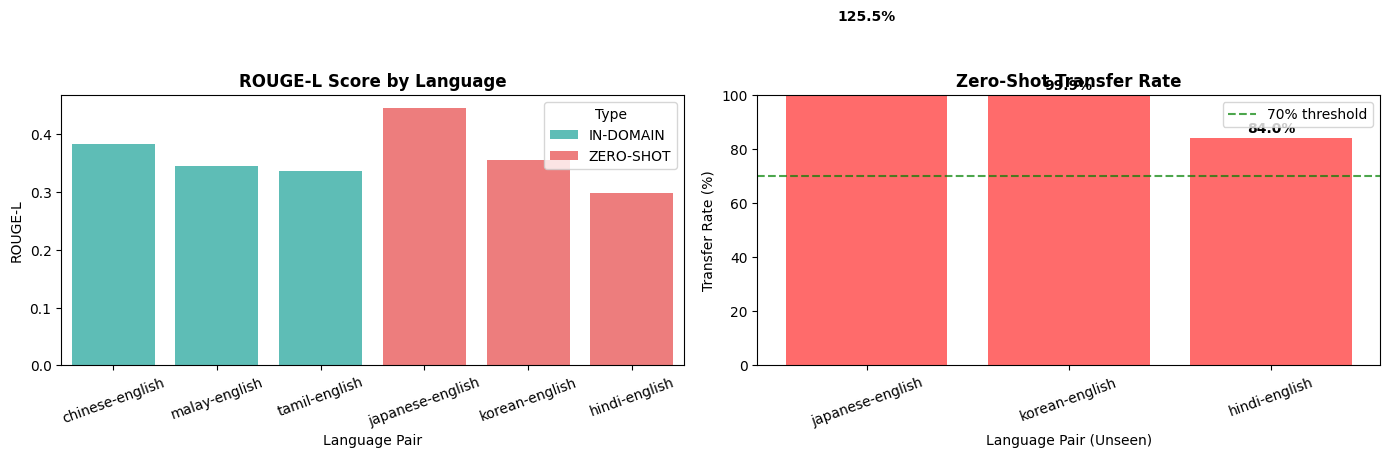

In [ ]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: ROUGE-L by language and type
ax1 = axes[0]
colors = {'IN-DOMAIN': '#4ECDC4', 'ZERO-SHOT': '#FF6B6B'}
sns.barplot(data=results_df, x='Language', y='rougeL', hue='Type', ax=ax1, palette=colors)
ax1.set_title('ROUGE-L Score by Language', fontsize=12, fontweight='bold')
ax1.set_xlabel('Language Pair')
ax1.set_ylabel('ROUGE-L')
ax1.tick_params(axis='x', rotation=20)
ax1.legend(title='Type')

# Plot 2: Transfer rates
ax2 = axes[1]
transfer_rates = []
for _, row in zero_shot_df.iterrows():
    transfer_rates.append({
        'Language': row['Language'],
        'Transfer Rate (%)': (row['rougeL'] / avg_in_domain) * 100
    })
transfer_df = pd.DataFrame(transfer_rates)

bars = ax2.bar(transfer_df['Language'], transfer_df['Transfer Rate (%)'], color='#FF6B6B')
ax2.axhline(y=70, color='green', linestyle='--', alpha=0.7, label='70% threshold')
ax2.set_title('Zero-Shot Transfer Rate', fontsize=12, fontweight='bold')
ax2.set_xlabel('Language Pair (Unseen)')
ax2.set_ylabel('Transfer Rate (%)')
ax2.set_ylim(0, 100)
ax2.legend()
ax2.tick_params(axis='x', rotation=20)

# Add value labels
for bar, rate in zip(bars, transfer_df['Transfer Rate (%)']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f'{rate:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('llama8b_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Save all results
results_df.to_csv('llama8b_results.csv', index=False)

# Save predictions
all_outputs = {
    'model': 'Llama-3.1-8B-Instruct',
    'training_languages': list(test_by_lang.keys()),
    'in_domain_predictions': in_domain_predictions,
    'zero_shot_predictions': zero_shot_predictions,
    'in_domain_test_data': {lang: [{'id': item['id'], 'summary': item['summary']} for item in items]
                            for lang, items in test_by_lang.items()},
    'zero_shot_test_data': {lang: [{'id': item['id'], 'summary': item['summary']} for item in items]
                            for lang, items in zero_shot_test.items()},
    'results': results
}

with open('llama8b_all_outputs.json', 'w', encoding='utf-8') as f:
    json.dump(all_outputs, f, indent=2, ensure_ascii=False)

# Copy to Drive
!cp llama8b_results.csv "{OUTPUT_DIR}"
!cp llama8b_all_outputs.json "{OUTPUT_DIR}"
!cp llama8b_results.png "{OUTPUT_DIR}"
!cp -r ./llama8b-codemixed-final "{OUTPUT_DIR}"

print(f"\n✓ All results saved to {OUTPUT_DIR}")


✓ All results saved to /content/drive/MyDrive/milestone3_llama8b/
